In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [2]:
image = cv2.imread('sar_2_color.jpg')

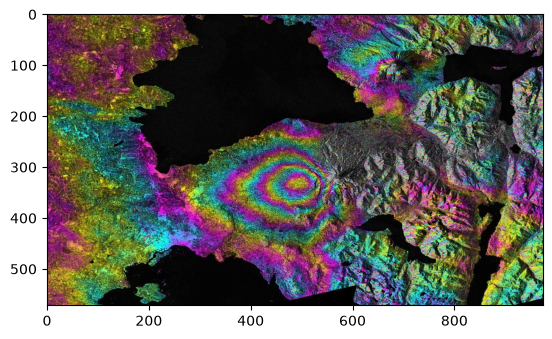

In [3]:
plt.imshow(image)

In [4]:
image.shape # h,w,c

(572, 974, 3)

In [5]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [6]:
# ROI
img_roi = image[100:200, 500:700]

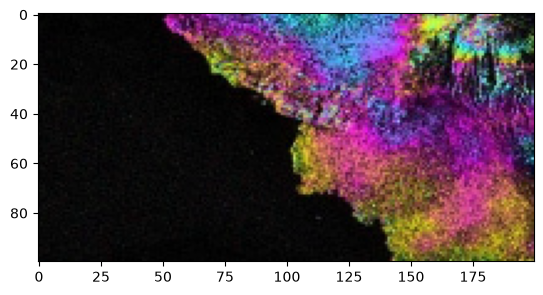

In [7]:
plt.imshow(img_roi)

In [8]:
b,g,r = cv2.split(image)

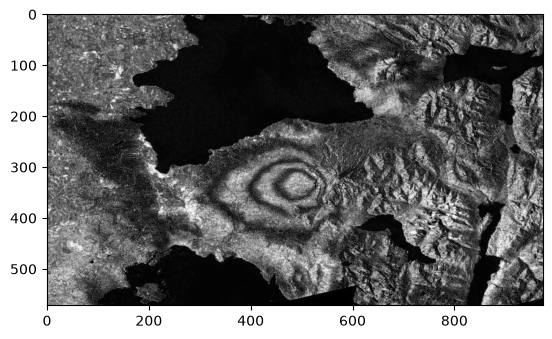

In [9]:
plt.imshow(b, cmap = 'gray')

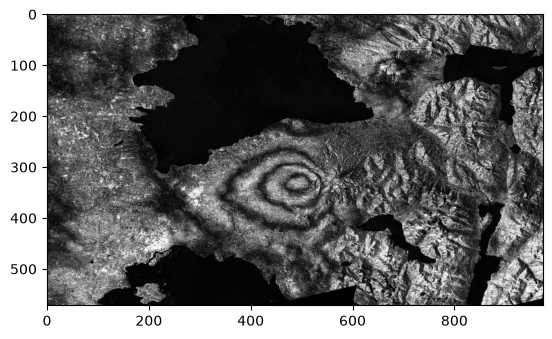

In [10]:
plt.imshow(g, cmap = 'gray')

In [11]:
# alternative approach
b = image[:,:,0]

In [12]:
import copy

image2 = copy.deepcopy(image)

In [13]:
image2[50:100,50:100] = [0,0,0]

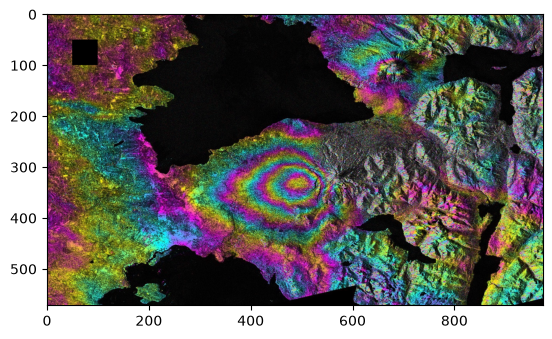

In [14]:
plt.imshow(image2)

In [15]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

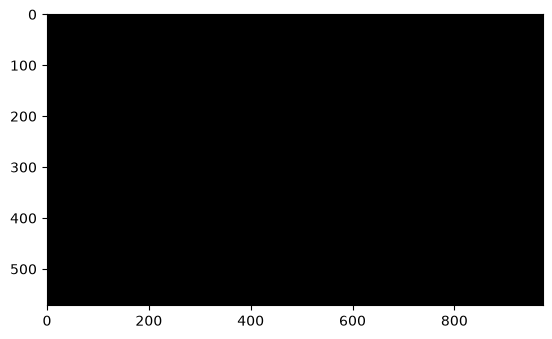

In [16]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [17]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [18]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [19]:
image_gray[0,0]

np.uint8(40)

In [20]:
image_gray.shape

(572, 974)

In [21]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [22]:
image_hsv.shape

(572, 974, 3)

In [23]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [24]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [25]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [26]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [27]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

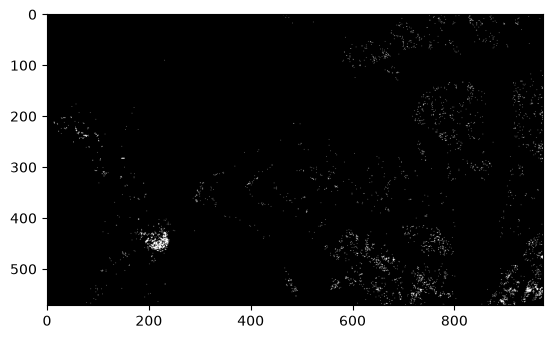

In [28]:
plt.imshow(thresh1, cmap='gray')

In [29]:
thresh1[thresh1==100].sum()

np.uint64(0)

# Построение гистограммы

In [30]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

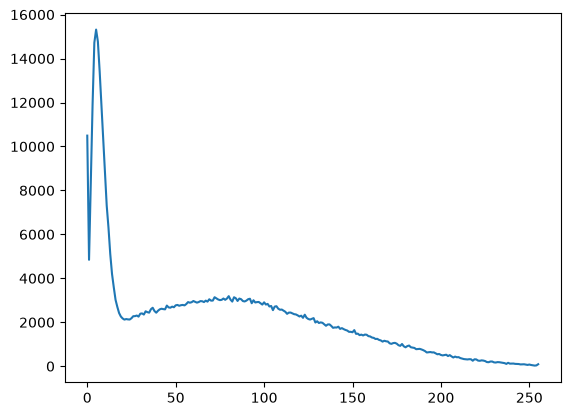

In [31]:
plt.plot(b_hist)

In [32]:
b_hist_cum = b_hist.cumsum()

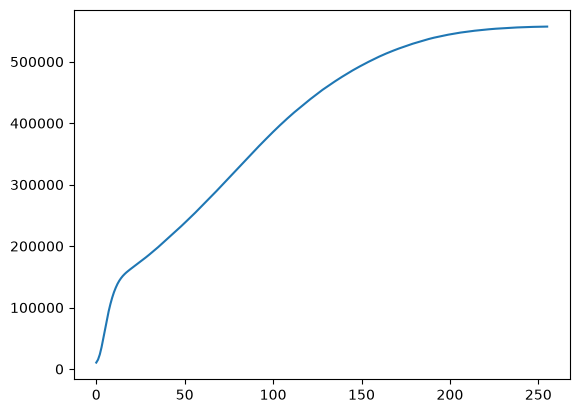

In [33]:
plt.plot(b_hist_cum)

In [34]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

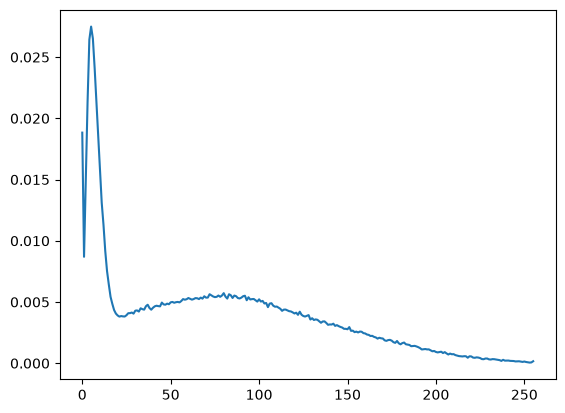

In [35]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [36]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


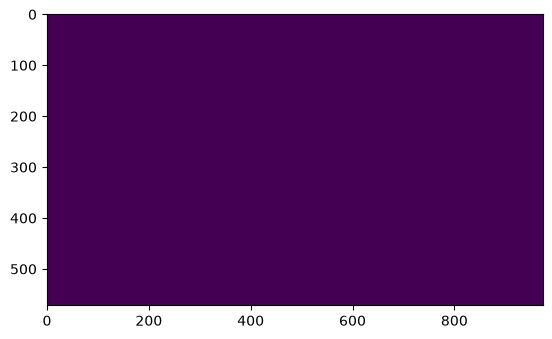

In [37]:
plt.imshow(diff)

In [38]:
mse = mean_squared_error(image_gray, image_gray)
mse

np.float64(0.0)

# Статистические характеристики изображений

In [39]:
mean = image_gray.mean()

In [40]:
std = image_gray.std()

In [41]:
print(mean,std)

67.41225535245043 52.01619187595963


In [42]:
eq_gray = cv2.equalizeHist(image_gray)

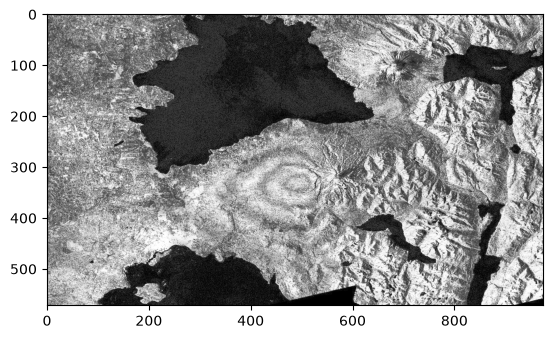

In [43]:
plt.imshow(eq_gray, cmap="gray")


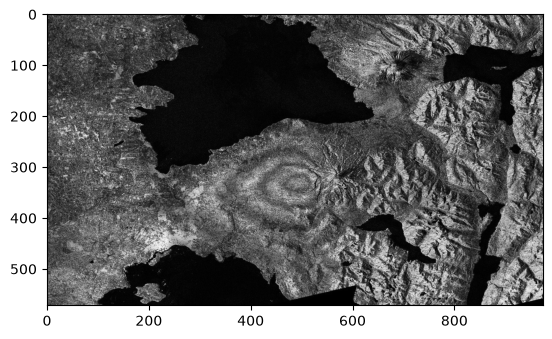

In [44]:
plt.imshow(image_gray, cmap="gray")

In [45]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

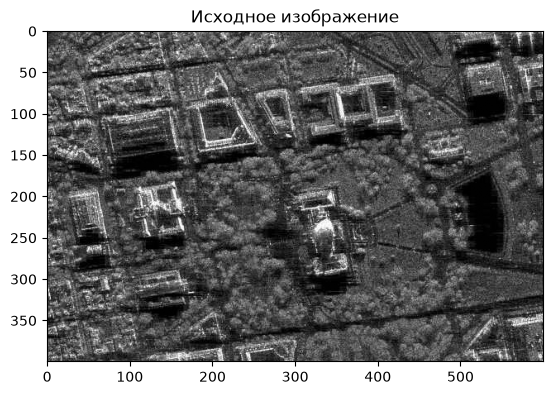

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

sar_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(sar_gray, cmap='gray')
plt.title('Исходное изображение')
plt.show()

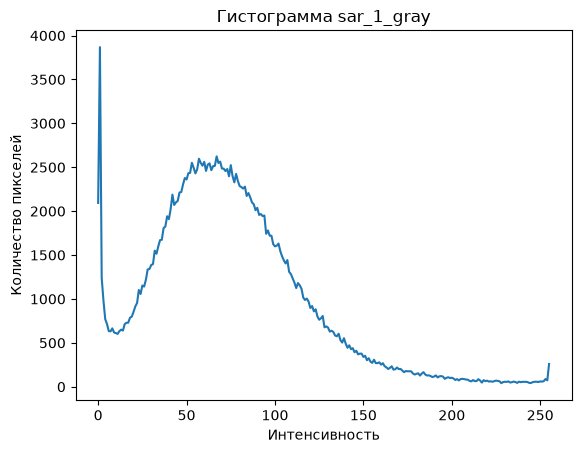

In [3]:
hist = cv2.calcHist([sar_gray], [0], None, [256], [0, 256])

plt.plot(hist)
plt.xlabel('Интенсивность')
plt.ylabel('Количество пикселей')
plt.title('Гистограмма sar_1_gray')
plt.show()

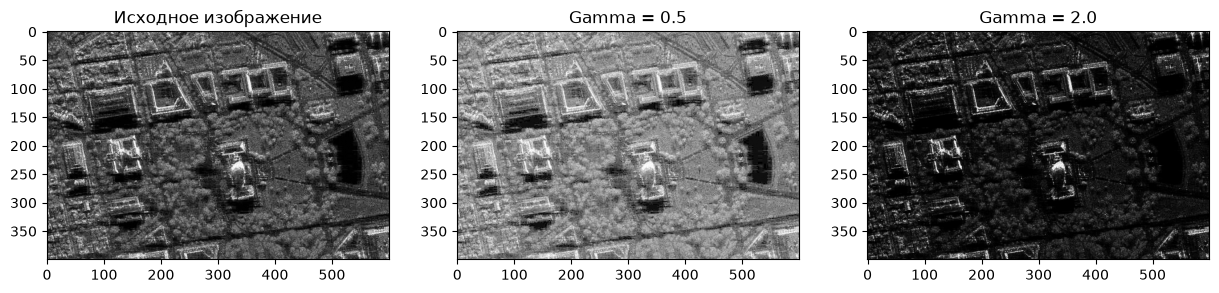

In [4]:
gamma1 = 0.5
gamma2 = 2.0

gamma_img1 = np.power(sar_gray / 255.0, gamma1) * 255
gamma_img1 = gamma_img1.astype(np.uint8)

gamma_img2 = np.power(sar_gray / 255.0, gamma2) * 255
gamma_img2 = gamma_img2.astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sar_gray, cmap='gray')
plt.title('Исходное изображение')

plt.subplot(1, 3, 2)
plt.imshow(gamma_img1, cmap='gray')
plt.title('Gamma = 0.5')

plt.subplot(1, 3, 3)
plt.imshow(gamma_img2, cmap='gray')
plt.title('Gamma = 2.0')

plt.show()

In [5]:
from skimage.metrics import mean_squared_error, structural_similarity

mse1 = mean_squared_error(sar_gray, gamma_img1)
ssim1 = structural_similarity(sar_gray, gamma_img1, data_range=255)

mse2 = mean_squared_error(sar_gray, gamma_img2)
ssim2 = structural_similarity(sar_gray, gamma_img2, data_range=255)

print("Gamma = 0.5")
print("MSE =", mse1)
print("SSIM =", ssim1)

print()

print("Gamma = 2.0")
print("MSE =", mse2)
print("SSIM =", ssim2)

Gamma = 0.5
MSE = 3258.3860041666667
SSIM = 0.7880009010140911

Gamma = 2.0
MSE = 2388.961375
SSIM = 0.5258442908010696


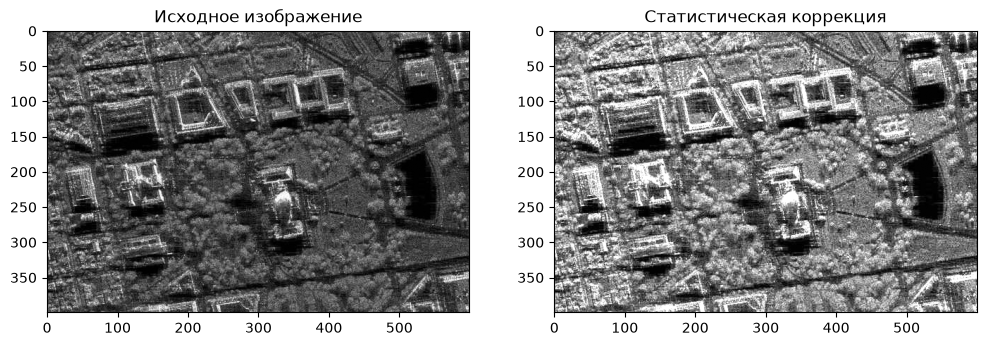

Среднее исходного = 74.9443875
Стандартное отклонение исходного = 43.38325832718397
Среднее eq_gray = 127.64575286110194
Стандартное отклонение eq_gray = 73.46412531208956


In [6]:
image = cv2.imread('sar_2_color.jpg')

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
eq_gray = cv2.equalizeHist(image_gray)

mean_sar = sar_gray.mean()
std_sar = sar_gray.std()

mean_eq = eq_gray.mean()
std_eq = eq_gray.std()

stat_corrected = (
    (sar_gray.astype(float) - mean_sar)
    * (std_eq / std_sar)
    + mean_eq
)

stat_corrected = np.clip(
    stat_corrected, 0, 255
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sar_gray, cmap='gray')
plt.title('Исходное изображение')

plt.subplot(1, 2, 2)
plt.imshow(stat_corrected, cmap='gray')
plt.title('Статистическая коррекция')

plt.show()

print("Среднее исходного =", mean_sar)
print("Стандартное отклонение исходного =", std_sar)
print("Среднее eq_gray =", mean_eq)
print("Стандартное отклонение eq_gray =", std_eq)

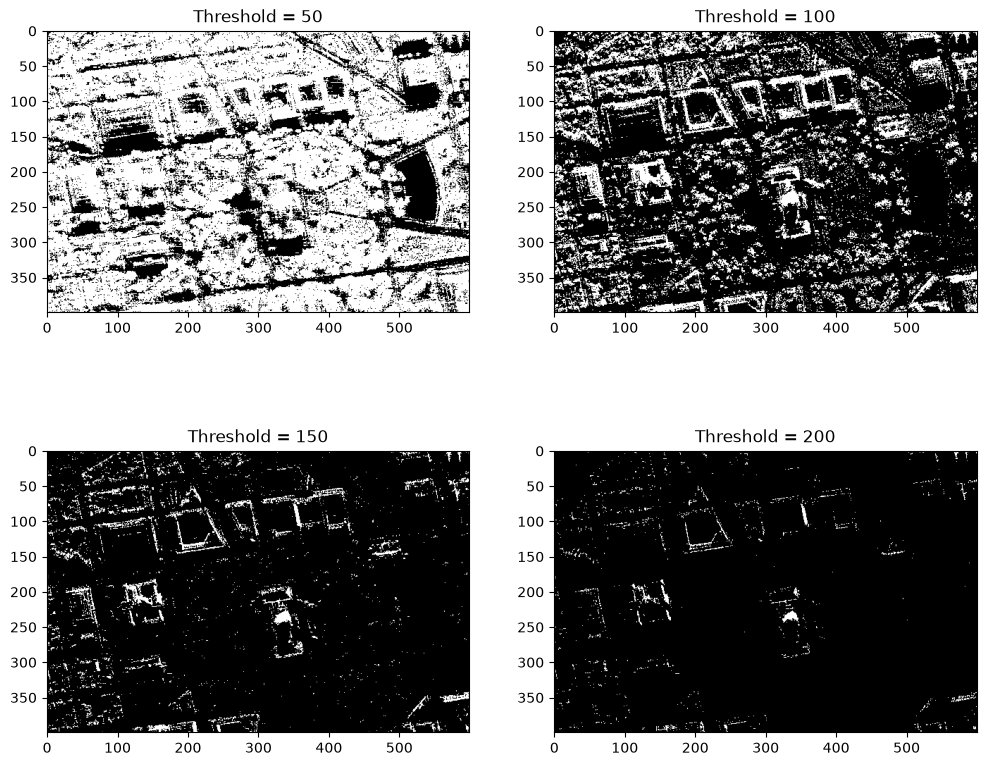

In [7]:
_, thresh50 = cv2.threshold(sar_gray, 50, 255, cv2.THRESH_BINARY)
_, thresh100 = cv2.threshold(sar_gray, 100, 255, cv2.THRESH_BINARY)
_, thresh150 = cv2.threshold(sar_gray, 150, 255, cv2.THRESH_BINARY)
_, thresh200 = cv2.threshold(sar_gray, 200, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(thresh50, cmap='gray')
plt.title('Threshold = 50')

plt.subplot(2, 2, 2)
plt.imshow(thresh100, cmap='gray')
plt.title('Threshold = 100')

plt.subplot(2, 2, 3)
plt.imshow(thresh150, cmap='gray')
plt.title('Threshold = 150')

plt.subplot(2, 2, 4)
plt.imshow(thresh200, cmap='gray')
plt.title('Threshold = 200')

plt.show()